# 02. Preprocessing

Continuing from `sold_df` in 01_exploration.ipynb (monthly-merged CRMLSSold*.csv data, Residential / SingleFamilyResidence), we run preprocessing here.

`fit` for preprocessing (missing-value imputation, scaling, encoding) must be done only on the train set, and only `transform` is applied to the test set and the final cleaned CSV.

**Week 6 update**: sections 9-13 add engineered features (`BedBathRatio`, `PropertyAge`, and a school-district spatial-join feature `SchoolDistrictGIS`) on top of the same preprocessing/split logic from before, and compare model performance on the old vs. the new feature set.


In [1]:
import glob
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42


## 1. Load merged dataset

If `merged_sales_data.csv` (created in 01_exploration.ipynb) already exists, load it directly.


In [2]:
df = pd.read_csv("merged_sales_data.csv", low_memory=False)
df["date"] = pd.to_datetime(df["date"])

df["year_month"] = df["date"].dt.to_period("M")
print(df.shape)
df.head()


(83495, 80)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,date,year_month
0,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,False,2.0,NaN,91901,NaN,NaN,NaN,2025-10-01,2025-10
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,False,2.0,NaN,92115,NaN,NaN,NaN,2025-10-01,2025-10
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,575000.0,1145277224,garylawrence@kw.com,...,NaN,False,2.0,NaN,91945,NaN,NaN,NaN,2025-10-01,2025-10
3,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1243810.0,1145272633,taylor@acme-re.com,...,NaN,True,NaN,NaN,90065,141.25,2066.0,NaN,2025-10-01,2025-10
4,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1227060.0,1145272243,taylor@acme-re.com,...,NaN,True,NaN,NaN,90065,141.25,1804.0,NaN,2025-10-01,2025-10


## 2. Define target and remove unusable rows

Rows with a missing target (`ClosePrice`) can't be used for training/evaluation, so they're dropped.


In [3]:
target = "ClosePrice"

before = len(df)
df = df.dropna(subset=[target]).copy()
print(f"Dropped {before - len(df)} rows with missing target ({target})")


Dropped 0 rows with missing target (ClosePrice)


## 3. Missing value overview

First check the missing-value ratio per column, then decide how to handle each one based on the following rule:

- Columns with a very high missing ratio (default: over 50%): treated as carrying little information, so the column itself is dropped
- Columns with some missing values: values are imputed (median for numeric, most_frequent for categorical), and `SimpleImputer(add_indicator=True)` automatically adds a flag (indicator) column marking which rows were originally missing

The threshold is controlled by a single `MISSING_DROP_THRESHOLD` variable.


In [4]:
MISSING_DROP_THRESHOLD = 0.5  # drop a column if more than 50% of it is missing

missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_report = missing_ratio[missing_ratio > 0].to_frame("missing_ratio")
print(f"Columns with missing values: {len(missing_report)} / {df.shape[1]}")
missing_report.head(20)


Columns with missing values: 61 / 80


,missing_ratio
MiddleOrJuniorSchoolDistrict,1.000000
AboveGradeFinishedArea,1.000000
BusinessType,1.000000
ElementarySchoolDistrict,1.000000
FireplacesTotal,1.000000
CoveredSpaces,1.000000
TaxYear,1.000000
TaxAnnualAmount,1.000000
WaterfrontYN,0.999437
BelowGradeFinishedArea,0.992778


In [5]:
high_missing_cols = missing_ratio[missing_ratio > MISSING_DROP_THRESHOLD].index.tolist()

# Exclude target/date-related columns in case they accidentally end up in the drop list
high_missing_cols = [c for c in high_missing_cols if c not in [target, "date", "year_month"]]

print(f"Columns dropped for exceeding {MISSING_DROP_THRESHOLD:.0%} missing ({len(high_missing_cols)}):")
print(high_missing_cols)

df = df.drop(columns=high_missing_cols)


Columns dropped for exceeding 50% missing (23):
['MiddleOrJuniorSchoolDistrict', 'AboveGradeFinishedArea', 'BusinessType', 'ElementarySchoolDistrict', 'FireplacesTotal', 'CoveredSpaces', 'TaxYear', 'TaxAnnualAmount', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName', 'LotSizeDimensions', 'BuildingAreaTotal', 'CoBuyerAgentFirstName', 'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool', 'CoListAgentFirstName', 'CoListAgentLastName', 'AssociationFeeFrequency', 'CoListOfficeName', 'SubdivisionName']


## 4. Feature selection (removing leakage / ID columns)

Besides the target and date-related columns, the following types are also excluded since they're unsuitable for model training:

- ID / key / URL / photo / free-text (remarks) columns: identified by keywords in the column name (see `LEAKAGE_KEYWORDS` below)
- Date-like object columns (e.g. `CloseDate`, `ContractStatusChangeDate`, `PurchaseContractDate`): detected by name suffix or by successfully parsing as a date. These either duplicate the `date`/`year_month` information (leakage) or, left as plain strings, would get OneHot-encoded into one category per calendar day
- High-cardinality object columns where nearly every value is unique (e.g. address strings, MLS numbers): >90% of rows have a distinct value
- Object columns with a large **absolute** number of categories (e.g. `City`, `PostalCode`, `MLSAreaMajor`, `HighSchoolDistrict`): these don't hit the 90%-unique threshold above, but OneHotEncoder would still turn each into hundreds of columns. `HighSchoolDistrict` is dropped here for this reason - section 9 replaces it with a more precise, boundary-verified geographic feature (`SchoolDistrictGIS`) built via spatial join
- Multi-label columns (comma-separated values, e.g. `Flooring: "Carpet,Tile,Wood"`): OneHotEncoder would treat every distinct *combination* of values as its own category. These are removed from the standard categorical pipeline and multi-hot encoded separately (see section 5)


In [6]:
LEAKAGE_KEYWORDS = [
    "id", "key", "url", "photo", "remark", "address", "street",
    "agent", "office", "mlsnumber", "mlsstatus", "listingcontract",
]

def looks_like_id_or_leakage(col_name: str) -> bool:
    name = col_name.lower()
    return any(kw in name for kw in LEAKAGE_KEYWORDS)

keyword_flagged = [c for c in df.columns if looks_like_id_or_leakage(c) and c not in [target]]

# Date-like object columns (e.g. CloseDate, ContractStatusChangeDate, PurchaseContractDate) are
# stored as strings, so they aren't caught by dtype checks. Detected by column-name suffix, or by
# successfully parsing a sample of values as dates. Left alone, these either duplicate `date`
# (leakage) or get OneHot-encoded into one category per calendar day.
def looks_like_date_column(series: pd.Series, col_name: str) -> bool:
    if col_name.lower().endswith("date"):
        return True
    if series.dtype == "object":
        sample = series.dropna().head(50)
        if len(sample) == 0:
            return False
        try:
            pd.to_datetime(sample, errors="raise")
            return True
        except (ValueError, TypeError):
            return False
    return False

date_like_flagged = [
    c for c in df.columns
    if c not in keyword_flagged
    and c not in [target]
    and looks_like_date_column(df[c], c)
]

# Object columns that are nearly all-unique (>90% of row count) are also treated as ID-like
object_cols = df.select_dtypes(include=["object"]).columns
high_cardinality_flagged = [
    c for c in object_cols
    if c not in keyword_flagged
    and c not in date_like_flagged
    and df[c].nunique(dropna=True) / len(df) > 0.9
]

# Object columns with a large ABSOLUTE number of categories (City, PostalCode, MLSAreaMajor,
# HighSchoolDistrict, ...) don't hit the 90%-unique ratio above, but still explode OneHotEncoder's
# column count and generalize poorly, especially with a short training window. Flagged separately
# with an absolute-count threshold. HighSchoolDistrict is intentionally caught here - section 9
# replaces it with SchoolDistrictGIS, a spatially-joined feature built from authoritative boundaries.
MAX_CATEGORY_COUNT = 50

too_many_categories_flagged = [
    c for c in object_cols
    if c not in keyword_flagged
    and c not in date_like_flagged
    and c not in high_cardinality_flagged
    and df[c].nunique(dropna=True) > MAX_CATEGORY_COUNT
]

# Multi-label columns (comma-separated values, e.g. Flooring: "Carpet,Tile,Wood") aren't true
# single categories - OneHotEncoder would treat each unique *combination* as its own category,
# exploding the column count. Removed here from the standard categorical pipeline and instead
# multi-hot encoded separately in section 5 (one 0/1 column per distinct value, not per combination).
MULTI_LABEL_COLS = ["Flooring"]
multi_label_flagged = [c for c in MULTI_LABEL_COLS if c in df.columns]

manual_drop_cols = [target, "date", "year_month"]

drop_cols = sorted(set(
    manual_drop_cols
    + keyword_flagged
    + date_like_flagged
    + high_cardinality_flagged
    + too_many_categories_flagged
    + multi_label_flagged
))
# Keep only columns that actually exist (some may already be gone via high_missing_cols)
drop_cols = [c for c in drop_cols if c in df.columns]

print(f"Final drop_cols ({len(drop_cols)}):")
print(drop_cols)


Final drop_cols (31):
['BuyerAgentAOR', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerOfficeName', 'City', 'CloseDate', 'ClosePrice', 'ContractStatusChangeDate', 'CountyOrParish', 'Flooring', 'HighSchoolDistrict', 'ListAgentAOR', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentFullName', 'ListAgentLastName', 'ListOfficeName', 'ListingContractDate', 'ListingId', 'ListingKey', 'ListingKeyNumeric', 'MLSAreaMajor', 'MlsStatus', 'PostalCode', 'PurchaseContractDate', 'StreetNumberNumeric', 'UnparsedAddress', 'date', 'year_month']


/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_68876/492651578.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample, errors="raise")
/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_68876/492651578.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample, errors="raise")
/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_68876/492651578.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample, errors="raise")
/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_68876/492651578.py:2

In [7]:
# Multi-label encoding: turn comma-separated values (e.g. Flooring: "Carpet,Tile,Wood") into
# individual 0/1 flag columns - one per distinct value (Flooring_Carpet, Flooring_Wood, ...),
# NOT one per combination. Merged directly into `df` (not just X) so that every later train/test
# split derived from `df` automatically carries these columns too.
for col in multi_label_flagged:
    dummies = df[col].fillna("").str.get_dummies(sep=",")
    dummies.columns = [f"{col}_{v}" for v in dummies.columns]
    df = pd.concat([df, dummies], axis=1)

X = df.drop(columns=drop_cols)
y = df[target]

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

# Latitude/Longitude are excluded from the model's inputs (but kept in `df` itself, since section 9
# still needs the raw coordinates for the school-district spatial join). Raw coordinates so strongly
# dominate a tree/linear model's location signal (see 02_preprocessing.ipynb's feature-importance
# section from the previous run: Latitude alone was the #1 feature by a wide margin) that any
# engineered geographic feature - SchoolDistrictGIS included - looks negligible by comparison. Removing
# them forces location information to come through more interpretable, purpose-built features instead.
EXCLUDE_FROM_MODEL = ["Latitude", "Longitude"]
numeric_cols = [c for c in numeric_cols if c not in EXCLUDE_FROM_MODEL]

print(f"numeric_cols ({len(numeric_cols)}): {numeric_cols}")
print(f"categorical_cols ({len(categorical_cols)}): {categorical_cols}")


numeric_cols (25): ['OriginalListPrice', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'Flooring_Bamboo', 'Flooring_Brick', 'Flooring_Carpet', 'Flooring_Concrete', 'Flooring_Laminate', 'Flooring_SeeRemarks', 'Flooring_Stone', 'Flooring_Tile', 'Flooring_Vinyl', 'Flooring_Wood']
categorical_cols (9): ['ViewYN', 'PoolPrivateYN', 'PropertyType', 'AttachedGarageYN', 'PropertySubType', 'StateOrProvince', 'FireplaceYN', 'Levels', 'NewConstructionYN']


## 5. Preprocessing pipeline

- Numeric: median imputation + flag (`add_indicator=True`) + StandardScaler
- Categorical: most_frequent imputation + flag + OneHotEncoder(`handle_unknown="ignore"`)

`build_pipeline` now takes `numeric_cols` / `categorical_cols` (and optionally a `model`) as arguments, instead of reading them from global variables. This lets the *same* function build a pipeline for the old feature set and, later, for the new (feature-engineered) one - see section 11.


In [8]:
def build_pipeline(numeric_cols, categorical_cols, model=None):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent", add_indicator=True)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        # On older scikit-learn (<1.2), use sparse=False instead of sparse_output
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )

    if model is None:
        model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])


## 6. Time-based train/test split

- Test set: data from the most recent month (`test_month`)
- Train set: the X months immediately preceding test_month (test_month itself is never included)
- X is not fixed but tuned; candidates [3, 6, 9, 12] are tried only within the range actually available in the data.

This window search uses the OLD feature set (`numeric_cols` / `categorical_cols` from section 4) purely to pick `best_X`. The resulting `best_train_months` / `test_month` are then reused unchanged for both the old and the new (feature-engineered) comparison in section 11, so that comparison isolates the effect of the new features rather than a different train/test split.


In [9]:
all_months = sorted(df["year_month"].unique())
test_month = all_months[-1]

months_available_for_train = len(all_months) - 1  # everything except test_month
candidate_windows = [w for w in [3, 6, 9, 12] if w <= months_available_for_train]

if not candidate_windows:
    # If very little data is available, fall back to a single maximal window
    candidate_windows = [months_available_for_train] if months_available_for_train >= 1 else []

if not candidate_windows:
    raise ValueError("No months are available to use as a training set. Check the date range of the data.")

print(f"All available months: {all_months}")
print(f"Test month: {test_month}")
print(f"Candidate training windows (months): {candidate_windows}")


All available months: [Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M')]
Test month: 2026-05
Candidate training windows (months): [3, 6]


In [10]:
results = []

for X_months in candidate_windows:
    train_months = all_months[-(X_months + 1):-1]

    train_df = df[df["year_month"].isin(train_months)].copy()
    test_df = df[df["year_month"] == test_month].copy()

    X_train = train_df.drop(columns=drop_cols)
    y_train = train_df[target]

    X_test = test_df.drop(columns=drop_cols)
    y_test = test_df[target]

    model = build_pipeline(numeric_cols, categorical_cols)
    model.fit(X_train, y_train)  # preprocessing is fit here, on train only

    pred = model.predict(X_test)  # only transform is applied to test (no leakage)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))  # squared=False was removed in newer sklearn, so use sqrt instead

    results.append({
        "training_window_months": X_months,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "train_months": [str(m) for m in train_months],
        "test_month": str(test_month),
        "MAE": mae,
        "RMSE": rmse,
    })

    print(f"[window={X_months:>2}] train_rows={len(train_df):>6} | MAE={mae:,.0f} | RMSE={rmse:,.0f}")


[window= 3] train_rows= 31758 | MAE=258,221 | RMSE=5,098,719
[window= 6] train_rows= 59442 | MAE=200,838 | RMSE=3,596,918


## 7. Compare X-month window performance


In [11]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values("RMSE").reset_index(drop=True)
results_df_sorted


,training_window_months,n_train_rows,n_test_rows,train_months,test_month,MAE,RMSE
0,6,59442,12024,"[2025-11, 2025-12, 2026-01, 2026-02, 2026-03, ...",2026-05,200837.503539,3.596918e+06
1,3,31758,12024,"[2026-02, 2026-03, 2026-04]",2026-05,258221.146312,5.098719e+06


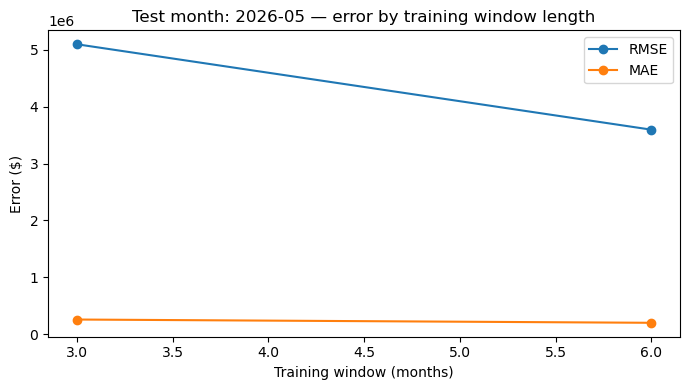

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(results_df["training_window_months"], results_df["RMSE"], marker="o", label="RMSE")
plt.plot(results_df["training_window_months"], results_df["MAE"], marker="o", label="MAE")
plt.xlabel("Training window (months)")
plt.ylabel("Error ($)")
plt.title(f"Test month: {test_month} — error by training window length")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Choose best X and rebuild final train/test split


In [13]:
best_X = int(results_df_sorted.iloc[0]["training_window_months"])
print(f"Best training window: {best_X} months (lowest RMSE)")

best_train_months = all_months[-(best_X + 1):-1]

train_df = df[df["year_month"].isin(best_train_months)].copy()
test_df = df[df["year_month"] == test_month].copy()

print(f"Final train months: {[str(m) for m in best_train_months]}")
print(f"Final test month: {test_month}")
print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")


Best training window: 6 months (lowest RMSE)
Final train months: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Final test month: 2026-05
Train rows: 59442 | Test rows: 12024


## 9. Feature engineering (Week 6)

Two simple engineered features, plus a more detailed geographic layer:

- `BedBathRatio`: `BedroomsTotal / BathroomsTotalInteger` - a single number capturing the balance between bedrooms and bathrooms, which the model would otherwise have to infer indirectly from the two raw counts
- `PropertyAge`: `sale year - YearBuilt` - how old the property was at the time of sale
- `SchoolDistrictGIS`: each property's (`Latitude`, `Longitude`) is spatially joined against the **CA School District Areas 2024-25** boundaries (CDE / data.ca.gov: https://data.ca.gov/dataset/california-school-district-areas-2024-25/resource/7dfaf005-58eb-45db-93b1-7aff091b2172), giving a boundary-verified district label. This directly replaces the MLS-provided `HighSchoolDistrict` field, which section 4 had to drop for being too high-cardinality (free-text, inconsistent naming). Note that the boundary file combines elementary/high/unified district layers into one file with overlapping geometries (a `Unified` district's area can also be covered separately by an `Elementary` and a `High` district), so a property can match more than one polygon; section 9.1 resolves this to a single label per property via an explicit priority rule rather than an arbitrary one

These are computed on `df` directly (not on `X`), so they flow through to `train_df` / `test_df` in section 11 the same way the multi-hot `Flooring` columns did in section 5.


In [14]:
df["BedBathRatio"] = df["BedroomsTotal"] / df["BathroomsTotalInteger"].replace(0, np.nan)
df.loc[(df["BedroomsTotal"] < 0) | (df["BathroomsTotalInteger"] < 0), "BedBathRatio"] = np.nan  # negative counts are data-entry errors, not real values

df["PropertyAge"] = df["date"].dt.year - df["YearBuilt"]
df.loc[(df["PropertyAge"] < 0) | (df["PropertyAge"] > 200), "PropertyAge"] = np.nan  # negative = YearBuilt after the sale date; >200 is implausible for this dataset - both treated as data errors

print(df[["BedBathRatio", "PropertyAge"]].describe())


       BedBathRatio   PropertyAge
count  83465.000000  83435.000000
mean       1.452564     49.538851
std        0.473531     27.647257
min        0.000000      0.000000
25%        1.000000     27.000000
50%        1.500000     49.000000
75%        1.500000     70.000000
max        7.500000    172.000000


### 9.1 School-district spatial join

Requires `geopandas` and `shapely` (`pip install geopandas shapely`, or `conda install -c conda-forge geopandas`). The boundaries are fetched from the CA Open Data GeoJSON export; if that URL is unreachable in your environment (no outbound internet, endpoint change, etc.), the code falls back to `SCHOOL_DISTRICT_LOCAL_PATH` - download the GeoJSON manually from the dataset page and place it there.

The dataset's schema isn't hardcoded here since exports can vary slightly - the district-name column is auto-detected from a list of likely candidates (confirmed as `DistrictName` the last time this was run), and the columns are printed so you can confirm or override `district_name_col` manually.


In [15]:
SCHOOL_DISTRICT_GEOJSON_URL = "https://gis.data.ca.gov/api/download/v1/items/b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
SCHOOL_DISTRICT_LOCAL_PATH = "CA_School_District_Areas_2024-25.geojson"  # fallback if the URL above is unreachable
# Direct download for the "Shapefile" resource of the same dataset, in case GeoJSON is unavailable:
# "https://gis.data.ca.gov/api/download/v1/items/b0e3b936426a47ce9d9a2e77e2bb86cc/shapefile?layers=0"

try:
    import geopandas as gpd
    from shapely.geometry import Point
except ImportError as e:
    raise ImportError(
        "This section needs geopandas + shapely. Install with: pip install geopandas shapely "
        "(or: conda install -c conda-forge geopandas)"
    ) from e

try:
    school_districts = gpd.read_file(SCHOOL_DISTRICT_GEOJSON_URL)
except Exception as e:
    if os.path.exists(SCHOOL_DISTRICT_LOCAL_PATH):
        print(f"Remote fetch failed ({e}); loading local fallback: {SCHOOL_DISTRICT_LOCAL_PATH}")
        school_districts = gpd.read_file(SCHOOL_DISTRICT_LOCAL_PATH)
    else:
        raise RuntimeError(
            f"Couldn't reach {SCHOOL_DISTRICT_GEOJSON_URL} and no local fallback found at "
            f"{SCHOOL_DISTRICT_LOCAL_PATH}. Download the GeoJSON from "
            "https://data.ca.gov/dataset/california-school-district-areas-2024-25 and save it "
            f"to {SCHOOL_DISTRICT_LOCAL_PATH}, or update SCHOOL_DISTRICT_LOCAL_PATH."
        ) from e

school_districts = school_districts.to_crs("EPSG:4326")  # match Latitude/Longitude (WGS84 decimal degrees)

print(f"Loaded {len(school_districts)} school district boundary polygons")
print(school_districts.columns.tolist())

NAME_CANDIDATES = ["DistrictName", "District", "NAME", "Name", "SDNAME", "DISTRICT"]
district_name_col = next((c for c in NAME_CANDIDATES if c in school_districts.columns), None)
if district_name_col is None:
    raise ValueError(
        f"Couldn't auto-detect the district name column. Available columns: {school_districts.columns.tolist()}. "
        "Set `district_name_col` manually to whichever column holds the district name."
    )
print(f"Using '{district_name_col}' as the district name column")


Loaded 937 school district boundary polygons
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'CongressUS', 'SenateCA', 'AssemblyCA', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'Shape__Area', 'Shape__Length', 'geometry']
Using 'DistrictName' as the district name column


In [16]:
# Rows without valid coordinates can't be spatially joined - they'll simply get SchoolDistrictGIS = NaN,
# which the categorical imputer (section 10) already knows how to handle. Coordinates are also checked
# against California's approximate bounding box (per the dataset's own extent) to catch bad values like
# (0, 0) or coordinates that slipped in from outside the state, which `notna()` alone wouldn't catch.
CA_LAT_RANGE = (32.5, 42.1)
CA_LON_RANGE = (-124.5, -114.0)

has_coords = (
    df["Latitude"].between(*CA_LAT_RANGE)
    & df["Longitude"].between(*CA_LON_RANGE)
)
print(f"Rows with usable in-state coordinates: {has_coords.sum()} / {len(df)}")

properties_gdf = gpd.GeoDataFrame(
    df.loc[has_coords, []],
    geometry=[Point(xy) for xy in zip(df.loc[has_coords, "Longitude"], df.loc[has_coords, "Latitude"])],
    crs="EPSG:4326",
)

join_cols = [district_name_col, "geometry"]
if "DistrictType" in school_districts.columns:
    join_cols.insert(1, "DistrictType")

# "intersects" (rather than "within") also catches properties that fall exactly on a district boundary
# line, which "within" can miss.
joined = gpd.sjoin(properties_gdf, school_districts[join_cols], how="left", predicate="intersects")

# Elementary and high school district boundaries can overlap the same area (per the dataset's own
# description - elementary/high/unified boundaries are combined into one file), so a single point can
# match more than one polygon (e.g. one Unified, or a separate Elementary + High pair). Rather than
# keeping an arbitrary "first" match, an explicit priority is used: Unified first (it's the single
# authoritative district for that area), then Elementary (typically the smaller, more locally specific
# boundary, and the level of school buyers of single-family homes most often search by), then High.
DISTRICT_PRIORITY = {"Unified": 0, "Elementary": 1, "High": 2}

if "DistrictType" in joined.columns:
    joined["_priority"] = joined["DistrictType"].map(DISTRICT_PRIORITY).fillna(99)
    joined = joined.sort_values("_priority")

joined = joined[~joined.index.duplicated(keep="first")]

df["SchoolDistrictGIS"] = pd.Series(np.nan, index=df.index, dtype="object")  # object dtype avoids a dtype-mismatch warning on assignment below
df.loc[joined.index, "SchoolDistrictGIS"] = joined[district_name_col].values

matched = df["SchoolDistrictGIS"].notna().sum()
print(f"Properties matched to a school district polygon: {matched} / {len(df)} ({matched / len(df):.1%})")


Rows with usable in-state coordinates: 83453 / 83495
Properties matched to a school district polygon: 83447 / 83495 (99.9%)


### 9.2 Control cardinality: bucket rare districts (fit on train only)

Raw district names would still be a few hundred distinct categories - similar to the `City` / `PostalCode` problem in section 4, this would blow up OneHotEncoder's column count. Instead of dropping the feature entirely (which would defeat the point of this week's task), the vocabulary of the top-N most frequent districts is computed **from the training rows only** (`best_train_months`), and everything else - in both train and test - is bucketed into `"Other"`. This keeps the feature usable while still respecting the "fit only on train" rule from the top of this notebook.

`TOP_N_DISTRICTS` trades off granularity against column count - a higher value keeps more districts distinguishable (more "detailed", per the Week 6 goal) but adds more one-hot columns; the coverage check below shows how much of the data ends up lumped into `"Other"` at the current setting, so it's easy to judge whether it needs to be raised.


In [17]:
TOP_N_DISTRICTS = 30

train_mask = df["year_month"].isin(best_train_months)
top_districts = df.loc[train_mask, "SchoolDistrictGIS"].value_counts().head(TOP_N_DISTRICTS).index

df["SchoolDistrictGIS"] = df["SchoolDistrictGIS"].where(
    df["SchoolDistrictGIS"].isin(top_districts) | df["SchoolDistrictGIS"].isna(),
    "Other",
)

other_share = (df["SchoolDistrictGIS"] == "Other").mean()
print(f"SchoolDistrictGIS categories after bucketing: {df['SchoolDistrictGIS'].nunique(dropna=True)}")
print(f"Share of rows bucketed into 'Other': {other_share:.1%} (raise TOP_N_DISTRICTS if this is too high)")
df["SchoolDistrictGIS"].value_counts(dropna=False).head(10)


SchoolDistrictGIS categories after bucketing: 31
Share of rows bucketed into 'Other': 58.9% (raise TOP_N_DISTRICTS if this is too high)


SchoolDistrictGIS
Other                   49205
Los Angeles Unified      8290
San Diego Unified        2288
Desert Sands Unified     1638
Capistrano Unified       1543
Palm Springs Unified     1433
Oakland Unified          1106
Corona-Norco Unified     1027
Long Beach Unified       1019
Hemet Unified            1005
Name: count, dtype: int64

## 10. Build the new (engineered) feature set

The engineered features join the existing numeric/categorical lists from section 4, giving `numeric_cols_new` / `categorical_cols_new`. The old lists (`numeric_cols_old` / `categorical_cols_old`) are kept as-is so both feature sets can be run through the same `build_pipeline()` and compared directly in section 11.

To avoid any ambiguity with the *original* (pre-Week-6) `02_preprocessing.ipynb`, the two feature sets are labeled explicitly below as `without_week6_features` and `with_week6_features` - both already include every fix from sections 3-4 (missing-value handling, leakage/ID/date/high-cardinality filtering, multi-hot `Flooring`); the only difference between them is the three features engineered in section 9.


In [18]:
numeric_cols_old = list(numeric_cols)
categorical_cols_old = list(categorical_cols)

numeric_cols_new = numeric_cols_old + ["BedBathRatio", "PropertyAge"]
categorical_cols_new = categorical_cols_old + ["SchoolDistrictGIS"]

BASE_LABEL = "without_week6_features"
NEW_LABEL = "with_week6_features"

print(f"{BASE_LABEL}: {len(numeric_cols_old) + len(categorical_cols_old)} raw columns "
      f"({len(numeric_cols_old)} numeric + {len(categorical_cols_old)} categorical)")
print(f"{NEW_LABEL}: {len(numeric_cols_new) + len(categorical_cols_new)} raw columns "
      f"({len(numeric_cols_new)} numeric + {len(categorical_cols_new)} categorical)")


without_week6_features: 34 raw columns (25 numeric + 9 categorical)
with_week6_features: 37 raw columns (27 numeric + 10 categorical)


## 11. Fit OLD vs NEW pipelines on the same train/test split & compare

`train_df` / `test_df` were built in section 8, **before** section 9 added the engineered columns to `df` - since they were `.copy()`'d at that point, they don't automatically pick up new columns added to `df` afterwards. They're rebuilt here from the (now feature-engineered) `df`, using the exact same `best_train_months` / `test_month`, so the row split itself is unchanged and only the columns differ.

Both feature sets are then evaluated with three models:

- `LinearRegression`
- `RandomForestRegressor` (unconstrained, default settings) - same as used earlier in this project
- `RandomForestRegressor (max_depth=5)` - 04_model_comparison.ipynb found that an unconstrained Random Forest badly overfits on this heavily one-hot-encoded feature space (deeply negative test R²), and that `max_depth=5` recovered the most performance among the depth candidates tried. It's included here so the old-vs-new comparison isn't dominated by that unrelated overfitting noise.

Each result row also records whether each of the three new features was included and how many columns the feature set expands to *after* One-Hot encoding (`n_features_encoded`), so the comparison table in section 12 makes the school-district layer's presence explicit rather than implying it through the row label alone.


In [19]:
# Rebuild train_df/test_df from the current df, which now includes BedBathRatio, PropertyAge,
# and SchoolDistrictGIS (section 8's train_df/test_df predate those columns and don't have them).
train_df = df[df["year_month"].isin(best_train_months)].copy()
test_df = df[df["year_month"] == test_month].copy()

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")


Train rows: 59442 | Test rows: 12024


In [20]:
def fit_and_evaluate(numeric_cols, categorical_cols, model, label, model_label):
    X_train = train_df.drop(columns=drop_cols)
    y_train = train_df[target]
    X_test = test_df.drop(columns=drop_cols)
    y_test = test_df[target]

    pipeline = build_pipeline(numeric_cols, categorical_cols, model=model)
    pipeline.fit(X_train, y_train)  # preprocessing + model both fit on train only
    pred = pipeline.predict(X_test)

    n_features_encoded = len(pipeline.named_steps["preprocessor"].get_feature_names_out())

    row = {
        "feature_set": label,
        "model": model_label,
        "bed_bath_ratio_included": "BedBathRatio" in numeric_cols,
        "property_age_included": "PropertyAge" in numeric_cols,
        "school_district_included": "SchoolDistrictGIS" in categorical_cols,
        "n_features_raw": len(numeric_cols) + len(categorical_cols),
        "n_features_encoded": n_features_encoded,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    }
    return row, pipeline


feature_sets = [
    (BASE_LABEL, numeric_cols_old, categorical_cols_old),
    (NEW_LABEL, numeric_cols_new, categorical_cols_new),
]

models = [
    ("LinearRegression", LinearRegression()),
    ("RandomForestRegressor (unconstrained)", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ("RandomForestRegressor (max_depth=5)", RandomForestRegressor(max_depth=5, random_state=RANDOM_STATE, n_jobs=-1)),
]

comparison_rows = []
fitted_pipelines = {}

for label, num_cols, cat_cols in feature_sets:
    for model_label, model in models:
        row, pipeline = fit_and_evaluate(num_cols, cat_cols, model, label, model_label)
        comparison_rows.append(row)
        fitted_pipelines[(label, model_label)] = pipeline
        print(f"[{label:>22} | {model_label:>38}] R2={row['R2']:.4f} | MAE={row['MAE']:,.0f} | RMSE={row['RMSE']:,.0f}")


[without_week6_features |                       LinearRegression] R2=0.6182 | MAE=239,543 | RMSE=1,036,822
[without_week6_features |  RandomForestRegressor (unconstrained)] R2=-3.5946 | MAE=200,838 | RMSE=3,596,918
[without_week6_features |    RandomForestRegressor (max_depth=5)] R2=-1.1823 | MAE=222,887 | RMSE=2,478,934
[   with_week6_features |                       LinearRegression] R2=0.6076 | MAE=256,232 | RMSE=1,051,229
[   with_week6_features |  RandomForestRegressor (unconstrained)] R2=-3.2215 | MAE=189,028 | RMSE=3,447,809
[   with_week6_features |    RandomForestRegressor (max_depth=5)] R2=-1.1276 | MAE=226,928 | RMSE=2,447,690


## 12. Old vs new feature set comparison table

`R2_change` / `MAE_change` / `RMSE_change` are computed per model (new minus old) via a pivot, rather than a plain `.diff()` on the row order, so the deltas are correct regardless of how the table happens to be sorted.


In [21]:
comparison_df = pd.DataFrame(comparison_rows)

pivoted = comparison_df.pivot(index="model", columns="feature_set", values=["R2", "MAE", "RMSE"])
deltas = pd.DataFrame({
    "R2_change": pivoted["R2"][NEW_LABEL] - pivoted["R2"][BASE_LABEL],
    "MAE_change": pivoted["MAE"][NEW_LABEL] - pivoted["MAE"][BASE_LABEL],
    "RMSE_change": pivoted["RMSE"][NEW_LABEL] - pivoted["RMSE"][BASE_LABEL],
}).reset_index()

comparison_df = comparison_df.merge(deltas, on="model", how="left")
comparison_df = comparison_df.sort_values(["model", "feature_set"]).reset_index(drop=True)

comparison_df.to_csv("feature_engineering_comparison.csv", index=False)
print("Saved feature_engineering_comparison.csv")
comparison_df


Saved feature_engineering_comparison.csv


,feature_set,model,bed_bath_ratio_included,property_age_included,school_district_included,n_features_raw,n_features_encoded,R2,MAE,RMSE,R2_change,MAE_change,RMSE_change
0,with_week6_features,LinearRegression,True,True,True,37,117,0.607554,256231.962885,1.051229e+06,-0.010684,16689.401460,14407.528946
1,without_week6_features,LinearRegression,False,False,False,34,80,0.618238,239542.561425,1.036822e+06,-0.010684,16689.401460,14407.528946
2,with_week6_features,RandomForestRegressor (max_depth=5),True,True,True,37,117,-1.127638,226927.757627,2.447690e+06,0.054665,4041.032980,-31244.486918
3,without_week6_features,RandomForestRegressor (max_depth=5),False,False,False,34,80,-1.182302,222886.724647,2.478934e+06,0.054665,4041.032980,-31244.486918
4,with_week6_features,RandomForestRegressor (unconstrained),True,True,True,37,117,-3.221545,189027.917428,3.447809e+06,0.373038,-11809.586111,-149108.973604
5,without_week6_features,RandomForestRegressor (unconstrained),False,False,False,34,80,-3.594583,200837.503539,3.596918e+06,0.373038,-11809.586111,-149108.973604


## 13. How much do the new engineered features actually matter?

Section 12 showed both models scoring slightly *worse* on the new feature set - before concluding the engineered features are unhelpful, it's worth checking how much the model actually relies on them. `RandomForestRegressor (max_depth=5)` on the new feature set is used here since it's the most stable of the three models trained above (see section 11's rationale) and, unlike Linear Regression's coefficients, `feature_importances_` isn't affected by collinearity between the new features and the raw columns they were derived from.


In [22]:
new_rf5_pipeline = fitted_pipelines[(NEW_LABEL, "RandomForestRegressor (max_depth=5)")]
preprocessor = new_rf5_pipeline.named_steps["preprocessor"]
rf5_model = new_rf5_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(rf5_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("Top 15 features overall:")
print(importances.head(15))

print("\nWhere do the 3 new engineered features rank?")
for raw_name in ["BedBathRatio", "PropertyAge"]:
    col = f"num__{raw_name}"
    if col in importances.index:
        rank = importances.index.get_loc(col) + 1
        print(f"  {raw_name:<16} importance={importances[col]:.4f}  (rank {rank} of {len(importances)})")

# SchoolDistrictGIS is one-hot encoded into many columns (one per bucketed district), so its
# importances are summed to get its total contribution as a single feature.
school_cols = [c for c in importances.index if c.startswith("cat__SchoolDistrictGIS")]
school_total = importances[school_cols].sum()
print(f"  {'SchoolDistrictGIS':<16} importance={school_total:.4f}  (summed across {len(school_cols)} one-hot columns)"
      f" - top district: {importances[school_cols].idxmax()}")


Top 15 features overall:
num__MainLevelBedrooms                           0.211900
cat__Levels_MultiSplit                           0.167749
num__ListPrice                                   0.153305
num__LotSizeArea                                 0.100186
num__YearBuilt                                   0.040876
num__ParkingTotal                                0.039499
num__OriginalListPrice                           0.030353
num__BedBathRatio                                0.029556
num__GarageSpaces                                0.028666
num__PropertyAge                                 0.025698
num__DaysOnMarket                                0.025099
cat__missingindicator_NewConstructionYN_True     0.019806
cat__missingindicator_NewConstructionYN_False    0.017140
num__LotSizeSquareFeet                           0.016076
cat__FireplaceYN_False                           0.014319
dtype: float64

Where do the 3 new engineered features rank?
  BedBathRatio     importance=0.0296  (rank 

## 14. Create cleaned CSVs (old backup + new main)

`cleaned_preprocessed_data.csv` is overwritten with the **new** (feature-engineered) version, since downstream notebooks (03, 04, ...) continue from this filename. The **old** version is saved separately as `cleaned_preprocessed_data_old.csv` so section 12's comparison stays reproducible even after this notebook is re-run.


In [23]:
def make_cleaned_csv(pipeline, out_path):
    X_cleaned = df.drop(columns=drop_cols)
    cleaned_array = pipeline.named_steps["preprocessor"].transform(X_cleaned)
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    cleaned = pd.DataFrame(
        cleaned_array.toarray() if hasattr(cleaned_array, "toarray") else cleaned_array,
        columns=feature_names,
        index=df.index,
    )
    cleaned[target] = df[target].values
    cleaned["year_month"] = df["year_month"].astype(str).values
    cleaned["date"] = df["date"].values
    cleaned["split"] = np.where(
        df["year_month"].isin(best_train_months), "train",
        np.where(df["year_month"] == test_month, "test", "unused")
    )
    cleaned.to_csv(out_path, index=False)
    print(f"Saved {out_path} - shape: {cleaned.shape}")
    return cleaned


old_pipeline = fitted_pipelines[(BASE_LABEL, "RandomForestRegressor (max_depth=5)")]
new_pipeline = fitted_pipelines[(NEW_LABEL, "RandomForestRegressor (max_depth=5)")]
# Only the fitted `preprocessor` step is used below, so it doesn't matter which of the three
# models above the pipeline happened to be attached to - the preprocessing itself is identical.

make_cleaned_csv(old_pipeline, "cleaned_preprocessed_data_old.csv")
cleaned_df = make_cleaned_csv(new_pipeline, "cleaned_preprocessed_data.csv")

results_df.to_csv("window_selection_results.csv", index=False)
print("Saved window_selection_results.csv")


Saved cleaned_preprocessed_data_old.csv - shape: (83495, 84)
Saved cleaned_preprocessed_data.csv - shape: (83495, 121)
Saved window_selection_results.csv


## Summary

- `Longitude` are also excluded from `numeric_cols` (though kept in `df` for the spatial join in section 9), since leaving them in let raw coordinates dominate the model and made it impossible to tell whether `SchoolDistrictGIS` was adding anything of its own
- New engineered features: `BedBathRatio`, `PropertyAge`, and `SchoolDistrictGIS`. The last built by spatially joining each property's (Latitude, Longitude) against the CA School District Areas 2024-25 boundaries, with overlapping Elementary/High/Unified matches resolved via an explicit priority rule, then bucketed to the top `TOP_N_DISTRICTS` most frequent districts in the training window + `"Other"` (58.9% of rows fall into `"Other"` at `TOP_N_DISTRICTS=30`). 

- **Both Random Forest variants improve** with the Week 6 features (higher R2, lower RMSE), while Linear Regression gets slightly worse.:
  - Removing `Latitude`/`Longitude` already dropped both Random Forest variants' R2 gap dramatically on their own - continuous coordinates had been giving the trees many narrow, overfit-prone geographic splits. With that overfitting surface removed, the trees then had room to benefit from the new features
  - Feature importance (section 13) on the depth-constrained Random Forest, new feature set: `SchoolDistrictGIS` (importance summed across its 31 one-hot columns) = **0.0320**, `BedBathRatio` = 0.0296 (rank 8 of 117), `PropertyAge` = 0.0257 (rank 10 of 117). 

- Deliverables: `cleaned_preprocessed_data.csv` (new, feature-engineered, overwrites the previous version, so **03_baseline_model.ipynb and 04_model_comparison.ipynb should be re-run** to reflect it), `cleaned_preprocessed_data_old.csv` (kept for reference/reproducibility), `feature_engineering_comparison.csv`, `window_selection_results.csv`, this updated notebook (save it as `02_preprocessing.ipynb`, replacing the previous version, so downstream notebooks and file references stay consistent)
